# 🎓 基于 Unsloth + GSPO 的 Qwen3-VL 强化学习实战


随着大模型从纯文本走向多模态，视觉语言模型（VLM）已经不仅仅用来“看图说话”，而是被期望完成更复杂的 `视觉理解 + 推理 + 决策` 任务。

但视觉语言模型 + 强化学习的训练通常对算力要求非常高，动辄需要 A100 / H100 等大显卡，耗时长、成本高。

但如果你只是想 学习整个方法流程、快速做 demo、验证想法是否可行，或者你的环境只有一张消费级 GPU（例如 RTX4090、3090）甚至云端短时体验资源 ——

👉 Unsloth 提供了一个极低门槛的解决方案。

- 通过 4bit 量化 + LoRA 低参数微调，可将显存需求降低 50% 以上

- 结合 vLLM 权重共享技术，推理速度快，适合交互式实验

- 非常适合 教学演示、科研方法验证以及 prototype 阶段的实验

Unsloth 的核心优势是针对“大模型 + 低资源环境”做了大量工程优化：在 VLM 任务中，它支持 4bit 量化 + LoRA 微调 + vLLM 权重共享，显著降低显存占用，同时保持推理和训练速度。针对视觉 RL，它已经帮你封装好 FastVisionModel、GRPO/GSPO 接口、reward 函数挂载方式，减少大量底层对接工作，让我们可以把精力集中在“数据和奖励设计”上，而不是“如何把图像塞进模型”的细节。

在本次课程中，我们将系统学习如何基于 Unsloth 框架，使用 GSPO（Group Sequence Policy Optimization）强化学习策略 对 Qwen3-8B-VL 视觉语言模型（VLM）进行高效参数微调。课程将从实战角度入手，围绕模型训练全流程展开。

通过今天的课程你将学习：

🔹 1. `数据准备`

理解 MathVista（AI4Math）数据集特点及筛选方式

学会 图片尺寸处理、颜色模式转换

掌握 多模态对话模板设计方法（含` <REASONING> 与 <SOLUTION>`）

🔹 2. `模型推理（推理前 baseline + 推理后对照）`

了解 如何将图像 + prompt 输入模型

学会 批量推理评估并提取答案格式

掌握 vLLM 快速推理

🔹 3. `强化学习训练（GSPO / GRPO）`

掌握 奖励函数设计思路与权重调控方式

理解 训练参数的影响（num_generations、batch、max_length、learning rate 等）

能够 读懂训练日志（reward 曲线、loss、kl、termination 率等）

🔹 4. `保存模型并重新加载使用`

学会 用 model.save_pretrained() 保存适配器

理解 保存内容的范围（LoRA 而非全模型）

能够 重新加载模型进行推理或继续训练


### 目录
一、安装环境  
二、Unsloth  
三、数据准备  
四、奖励函数  
五、直接推理  
六、模型训练  
七、训练后推理  
八、保存、加载训练后的模型  

## 一、安装环境

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.57.0
!pip install --no-deps trl==0.22.2

判断系统环境变量是否包含 "COLAB_" 字符串。

如果不是 Colab 环境 ➜ 直接安装 unsloth。再安装指定版本transformers & TRL。

如果是 Colab 环境

- 先获取 torch 的版本号（提取数字部分）
- 根据 PyTorch 版本选择 不同版本的 xformers
（xformers 是 Meta 开源的 transformer 加速库，版本不兼容容易报错）
    - no-deps：不安装其依赖，避免和 Colab 自带库冲突
    - bitsandbytes：低精度训练（8bit/4bit）核心库
    - accelerate：Hugging Face 的训练加速框架
    - {xformers}：前面根据 torch 版本动态确定的版本
    - peft：参数高效微调 (LoRA 等方法)
    - trl：Transformer Reinforcement Learning 库，用于 GRPO 等 RLHF 方法
    - triton：NVIDIA GPU 内核优化工具
    - cut_cross_entropy：用于提升训练效率 - 
    - unsloth_zoo：Unsloth 扩展工具包
    - sentencepiece：用于 BPE/分词模型
    - protobuf：模型保存格式依赖
    - datasets：控制版本范围，避免和 Colab 自带版本冲突
    - huggingface_hub：用于从 HuggingFace 拉模型
    - hf_transfer：加速模型上传下载
    - 单独安装unsloth
- 安装指定版本transformers & TRL
（Colab 自带很多预装包，GPU / CUDA 版本不固定，会产生依赖冲突。）

## 二、Unsloth

#### “看图做数学题”的 VLM 强化学习

目标是：让一个视觉语言模型（VLM）在看到一张图片后，学会解数学题。

- 输入：图像（比如图里的几何/表格/图表等数学题）
- 输出：详细的推理步骤 + 最终答案
- 优化方式：通过 RL（比如 GSPO）来奖励“答案正确＋推理格式合理”的输出。

<img src="https://raw.githubusercontent.com/lupantech/MathVista/main/assets/our_new_3_datasets.png" alt="Alt text" height="256">

### 2.1 通过Unsloth加载模型

> 注意这里代码会自动连接HuggingFace按照model_name去下载对应的模型文件，需要你的本机可连接对应网站。
> 如果无法连接Huggingface，你需要下载该模型，替换模型导入的代码为下面的内容。

```
from unsloth import FastVisionModel
import torch

max_seq_length = 16384  # Must be this long for VLMs
lora_rank = 16  # Larger rank = smarter, but slower

# ✅ 使用本地模型路径（指向 snapshots 下的实际模型目录）
local_model_dir = (
    "/home/.cache/huggingface/hub/models--unsloth--Qwen3-VL-8B-Instruct-unsloth-bnb-4bit"
    "/snapshots/b5b904c3fcdc7541adf2a2bb219b0ed95288c794"
)

model, tokenizer = FastVisionModel.from_pretrained(
    model_name=local_model_dir,  # ✅ 使用本地路径
    max_seq_length=max_seq_length,
    load_in_4bit=True,
    fast_inference=False,
    gpu_memory_utilization=0.8,
    local_files_only=True,  # ✅ 强制只使用本地文件，不尝试从网络下载
)
```

In [2]:
from unsloth import FastVisionModel
import torch
max_seq_length = 16384 # Must be this long for VLMs
lora_rank = 16 # Larger rank = smarter, but slower

model, tokenizer = FastVisionModel.from_pretrained(
    model_name = "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit",
    max_seq_length = max_seq_length,
    load_in_4bit = True, # False for LoRA 16bit
    fast_inference = False, # Enable vLLM fast inference
    gpu_memory_utilization = 0.8, # Reduce if out of memory

)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.11.3: Fast Qwen3_Vl patching. Transformers: 4.57.0.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.367 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 2/2 [00:41<00:00, 20.60s/it]


1️⃣ 超长序列长度：max_seq_length = 16384

为了让模型既“装得下图像信息”，又能“写超长解题过程”，因此必须把序列长度拉到 16k。

视觉语言模型的输入不是只有文字：

- 图片会被编码成很多视觉 token

- 再加上：

    - 系统 prompt

    - 问题文字

    - 模型生成的长推理过程（比如我们本案例中详细数学解题步骤）

2️⃣ LoRA 的秩就像“给模型加几个新脑回路”，多了会更聪明，但也更费脑子（显存和时间）。

Rank 越大 → 可学习参数越多 → 表示能力更强，可以拟合更复杂的更新

3️⃣ FastVisionModel 是什么？

Unsloth 提供的一个封装好的视觉语言模型加载器。

它可以将
- 文本模型
- 视觉编码部分
- 量化 / LoRA / 加速配置

整合成一个 好用的 model, tokenizer 接口。

(1) 模型名称"unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit"

Qwen3-VL-8B-Instruct
- Qwen3 系列，8B 参数的视觉语言指令模型

- “VL” = Vision-Language，有看图能力

- “Instruct” = 已经做过指令调优，适合对话式任务

unsloth-bnb-4bit

- unsloth 表示经过 Unsloth 做过格式和加速适配

- bnb-4bit 表示使用 bitsandbytes 4 比特量化：

    - 占用显存显著下降

    - 非常适合 Colab 或 1 张消费级显卡上做 LoRA 微调

(2) 用 4bit 量化加载基础模型权重,“4bit base + 16bit LoRA”的经典配置。

如果改成 False：模型会用 16bit 精度加载

(3) 关闭加速推理
**fast_inference = False** 

如果设成 True，会走接近 vLLM 之类的高速推理路径（适合纯推理场景）

(4) GPU分配

最多使用 80% 的显存 来布置权重和缓存，剩下的给计算图、优化器状态、或者其它库的显存开销。如果你老是OOM，也可以再降低这个比率。

### 2.2 模型封装为LoRA模型

在 Unsloth 里，推理部分使用 vLLM，Unsloth 直接和 vLLM 共享模型权重，这样就不用复制一份模型在显存里，显存占用可以减少一半以上。

**LoRA 目前只能加在“语言层”，不能加在“视觉层”**

当前 vLLM 还没有很好支持在“视觉编码层”上挂 LoRA，

所以这份 Notebook 里 **只在语言层（Transformer 文本部分）加 LoRA。**

但这不影响我们做 “Vision GRPO”：

- 输入里仍然有图片

- 模型依然是“图 + 文”联合推理

- 奖励和 GRPO 仍然是基于“看图解题”的行为来优化的。

如果一定要对视觉层加 LoRA，，就要放弃 vLLM 那一套超强加速，回到传统 HF + PEFT 的训练路径。

伪代码：
```
from transformers import AutoModelForVision2Seq   # 视具体模型架构
from peft import LoraConfig, get_peft_model

config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["vision_blocks.*.attn.q_proj", "vision_blocks.*.attn.v_proj"],
    lora_dropout=0.05,
    bias="none",
)
model = get_peft_model(model, config)

```
但显存占用很大，推理速度很慢，目前没有很成熟的方法，都在做探索。如果你是做科研实验，想验证“视觉层微调对你当前的任务到底有没有效果”，可以试一试。

In [3]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = False, # 不微调视觉层
    finetune_language_layers   = True,  # 微调语言层
    finetune_attention_modules = True,  # 微调注意力层
    finetune_mlp_modules       = True,  # 微调MLP层（前馈网络）

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    use_gradient_checkpointing = "unsloth", # Reduces memory usage
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

1️⃣ 决定“微调哪些部分”

生动的理解就是，我们把模型分成“眼睛”和“大脑”：

- 眼睛（视觉编码器）现在不改，保持稳定

- 大脑（语言 Transformer）上加 LoRA，用 RL 让它学会更靠谱的解题和表述方式。

我们强化学习训练的是我们对看到事物的理解方式，而不是视觉的精度或者范围。

2️⃣ LoRA 的核心超参数

- LoRA 的秩=16 越大学习越细化，但也容易过拟合和消耗显存
- 缩放因子lora_alpha = 16，经验来看alpha 通常 ≥ r
- LoRA 层内的 dropout，设 0 表示不过滤。如果数据少、容易过拟合，可以开一点点（比如 0.05）
- 不对原有 bias 做可训练更新，进一步减少可训练参数，保持轻量。
- 随机数种子 random_state = 3407

3️⃣ 更高级的 LoRA 变体开关

use_rslora：Rank-Stabilized LoRA，一种改进版 LoRA，目标是在提高 rank 时保持训练更稳定，不至于梯度爆炸或训练发散。

loftq_config：LoftQ 是一种 量化 + LoRA 结合策略，用来在进一步量化模型时让 LoRA 也能适配得更好。

这里默认关闭用标准版LoRA即可。

4️⃣ 显存优化：梯度检查点

- 训练时不保存每一层的中间激活，

- 反向传播时再临时重算一部分前向过程，

- 用“计算换显存”，显存占用能显著降低。

"unsloth" 表示用 Unsloth 自己优化过的一套策略。

## 三、数据准备


### 3.1 数据集介绍

**数据集：MathVista（由 微软AI4Math 在ICLR 2024 发布）**

- 数据集基准榜：https://mathvista.github.io/ 

- 项目地址：https://github.com/lupantech/MathVista 

- 数据地址：https://huggingface.co/datasets/AI4Math/MathVista 

- 论文地址：https://openreview.net/forum?id=KUNzEQMWU7 

总体包含 6,141 道题目，来自 31 个子数据集/源（28 个已有数据集 + 新标注的 3 个：IQTest、FunctionQA、PaperQA）

每题不仅有“文字问题”，还有对应的图片（图表、几何图、函数图像、科学图像等）作为视觉输入。

分成两个子集：

- testmini（1,000 例，用于模型开发/验证）
- test（约 5,141 例，用于标准评测，且答案不公开）

题目类型多样：多选题（multi_choice）;自由形式填空（free_form），答案类型可以是整数、浮点数、列表等。


In [4]:
from datasets import load_dataset
from trl import GRPOConfig, GRPOTrainer

dataset = load_dataset("AI4Math/MathVista", split = "testmini")

### 3.2 数据过滤清洗

下面代码中做了过滤：只保留那些“答案可转为 float（即数值答案）”的数据。我们强化学习后续要做“数学题 + 数字答案”这种设置，更聚焦于“数值输出”类别。如果是证明题目或者分析题目，可能没有绝对的正确与否，我们强化学习的奖励判定部分需要更复杂的判定模型。而且同一类型的题目也可以让训练目标更加一致，有更好的强化学习训练效果。

函数 is_numeric_answer 检查每个样本：尝试把 example["answer"] 转换成 float。

如果能成功转换，说明这个答案是数值型（可能是整数或者浮点数），标记为True，作为我们最终训练的数据。

In [5]:
def is_numeric_answer(example):
    try:
        float(example["answer"])
        return True
    except:
        return False

dataset = dataset.filter(is_numeric_answer)

在视觉数据预处理阶段对图片进行统一尺寸和格式转换

我们把图片统一到 512×512 的三通道 RGB 图像，是为了减少视觉 token 占用上下文长度，并确保模型能够正确读取图像格式。

图像原始可能是：RGBA（带透明通道）L（灰度图）P（调色板模式）或 RGB（标准 3 通道）

大多数大模型支持的是 RGB 三通道格式（R/G/B）

In [6]:
# Resize to (512, 512)
def resize_images(example):
    image = example["decoded_image"]
    image = image.resize((512, 512))
    example["decoded_image"] = image
    return example
dataset = dataset.map(resize_images)

# Then convert to RGB
def convert_to_rgb(example):
    image = example["decoded_image"]
    if image.mode != "RGB":
        image = image.convert("RGB")
    example["decoded_image"] = image
    return example
dataset = dataset.map(convert_to_rgb)

### 3.3 RL可用对话格式转换

> “把原始数据，整理成适合 VLM + RL 的提示结构”

包括：

1. 多模态输入：图片 + 问题统一在一个 user 消息里

2. 稳定的输出约束：用"`<REASONING> / <SOLUTION>`"结构规范输出格式

3. 适配具体模型的 chat 模板：用 tokenizer.apply_chat_template 生成正确的 prompt 字符串

这样 RL loop 才能做：

- 让模型按规范生成：

`<REASONING>...推理...</REASONING><SOLUTION>3.14</SOLUTION>`

- 从输出中解析出最终数字；

- 和 GT 答案 example["answer"] 对比 → 计算 reward → 用 GRPO/GSPO 更新策略。

In [7]:
# Define the delimiter variables for clarity and easy modification
REASONING_START = "<REASONING>"
REASONING_END = "</REASONING>"
SOLUTION_START = "<SOLUTION>"
SOLUTION_END = "</SOLUTION>"

def make_conversation(example):
    # Define placeholder constants if they are not defined globally
    # The user's text prompt
    text_content = (
        f"{example['question']}. Also first provide your reasoning or working out"\
        f" on how you would go about solving the question between {REASONING_START} and {REASONING_END}"
        f" and then your final answer between {SOLUTION_START} and (put a single float here) {SOLUTION_END}"
    )

    # Construct the prompt in the desired multi-modal format
    prompt = [
        {
            "role": "user",
            "content": [
                {"type": "image"},  # Placeholder for the image
                {"type": "text", "text": text_content},  # The text part of the prompt
            ],
        },
    ]
    # The actual image data is kept separate for the processor
    return {"prompt": prompt, "image": example["decoded_image"], "answer": example["answer"]}

train_dataset = dataset.map(make_conversation)

# We're reformatting dataset like this because decoded_images are the actual images
# The "image": example["decoded_image"] does not properly format the dataset correctly

# 1. Remove the original 'image' column
train_dataset = train_dataset.remove_columns("image")

# 2. Rename 'decoded_image' to 'image'
train_dataset = train_dataset.rename_column("decoded_image", "image")

1️⃣ text_content 就是 给模型的“任务说明 + 问题本身”：

- 先把原始数学问题 example['question'] 放进去；

- 再加一句非常明确的指示：

    - 先在` <REASONING>...</REASONING> `里写推理过程；

    - 然后在` <SOLUTION>...</SOLUTION> `里写 单个浮点数 作为答案。

相当于一个 强格式化 Prompt,限制模型输出格式。

2️⃣ 多模态 prompt

把 “图片 + 文本问题” 打包成一个 Chat 格式的多模态对话，让后面的 tokenizer 知道：

- 用户发了一条消息

- 里面既有图像，又有文字指令。

3️⃣ 视觉列标注

Hugging Face 的视觉处理 / processor 通常默认用 "image" 这一列。

原始数据集中有`image`列，但其为图像的存储路径`images/1.jpg`,真正的图像在`decoded_image`数据列下，已近在上一步被我们转换为统一的RGB格式。


下面进行数据集划分：
如果不需要直接跳过这个代码块即可

In [8]:
from datasets import DatasetDict

# 这里的 train_dataset 其实是“整个可用数据”，我们先重命名一下避免误会
full_dataset = train_dataset

# 按样本数量划分，约 100 条用作测试集
# 如果总数 < 100，可以改成 test_size=0.2 之类的比例
split_dataset = full_dataset.train_test_split(test_size=100, seed=42)

train_dataset = split_dataset["train"]   # 用于 RL 训练
eval_dataset  = split_dataset["test"]    # 用于 baseline & 训练后测试

print("Train size:", len(train_dataset))
print("Eval size:", len(eval_dataset))


Train size: 466
Eval size: 100


最后套上 tokenizer 的 chat template,之前的 chat 结构是“人类可读的 JSON 结构”，apply_chat_template 是“把它翻译成模型喜欢的那种 prompt 字符串格式”，包括系统 token、角色标签、特殊 image 占位符等。

**从“结构化 chat 列表”变成“真实要喂给模型的 Prompt 字符串”**

In [9]:
train_dataset = train_dataset.map(
    lambda example: {
        "prompt": tokenizer.apply_chat_template(
            example["prompt"],
            tokenize = False,
            add_generation_prompt = True, # Must add assistant
        )
    }
)

In [10]:
eval_dataset = eval_dataset.map(
    lambda example: {
        "prompt": tokenizer.apply_chat_template(
            example["prompt"],
            tokenize = False,
            add_generation_prompt = True, # Must add assistant
        )
    }
)

输入一个类似这样的结构:
```
example["prompt"] = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "...<REASONING>...</REASONING>..."},
        ],
    }
]

```
模型的 tokenizer 内部有一个 “chat template”，会把它转换成：
```
<|im_start|>user
<image>
题目内容 + 指令 + 标签说明
<|im_end|>
<|im_start|>assistant

```
这是Qwen-VL 官方标准模板，不同模型的模板有差异

## 四、奖励函数

我们怎么用“字符串规则”去给大模型的输出打分？

这分为 `格式奖励` 和 `正确性奖励`

We also try to fix the `addCriterion` issue as described in our [blog post](https://docs.unsloth.ai/new/vision-reinforcement-learning-vlm-rl#qwen-2.5-vl-vision-rl-issues-and-quirks)

In [11]:
# Reward functions

import re

FORMAT_WEIGHT = 0.3
def formatting_reward_func(completions,**kwargs):
    import re
    thinking_pattern = f'{REASONING_START}(.*?){REASONING_END}'
    answer_pattern = f'{SOLUTION_START}(.*?){SOLUTION_END}'

    scores = []
    for completion in completions:
        score = 0
        thinking_matches = re.findall(thinking_pattern, completion, re.DOTALL)
        answer_matches = re.findall(answer_pattern, completion, re.DOTALL)
        if len(thinking_matches) == 1:
            score += 1.0
        if len(answer_matches) == 1:
            score += 1.0

        # Fix up addCriterion issues
        # See https://docs.unsloth.ai/new/vision-reinforcement-learning-vlm-rl#qwen-2.5-vl-vision-rl-issues-and-quirks
        # Penalize on excessive addCriterion and newlines
        if len(completion) != 0:
            removal = completion.replace("addCriterion", "").replace("\n", "")
            if (len(completion)-len(removal))/len(completion) >= 0.5:
                score -= 2.0

        scores.append(FORMAT_WEIGHT *score)
    return scores

CORRECT_WEIGHT = 1.0
def correctness_reward_func(prompts, completions, answer, **kwargs) -> list[float]:
    import re
    answer_pattern = f'{SOLUTION_START}(.*?){SOLUTION_END}'

    responses = [re.findall(answer_pattern, completion, re.DOTALL) for completion in completions]
    q = prompts[0]
    print('-' * 20, f"Question:\n{q}", f"\nAnswer:\n{answer[0]}", f"\nResponse:{completions[0]}")

    def to_number(x: str):
        try:
            return float(x.strip())
        except Exception:
            return None

    def score_one(r, a) -> float:
        # r 是当前样本里提取到的所有答案片段列表，a 是标准答案
        if len(r) != 1:
            return 0.0

        pred_text = r[0].replace('\n', '').strip()
        gold_text = a.strip()

        # ① 完全字符串相等 → 2 分
        if pred_text == gold_text:
            base = 2.0

        # ② 字符串不相等，但数值等价（比如 3 vs 3.0）→ 1.5 分
        pred_num = to_number(pred_text)
        gold_num = to_number(gold_text)
        if (
            pred_num is not None
            and gold_num is not None
            and abs(pred_num - gold_num) < 1e-8
        ):
            base = 1.5
        else:
        # ③ 其他情况 → 0 分
            base = 0.0
        return CORRECT_WEIGHT * base

    return [
        score_one(r, a)
        for r, a in zip(responses, answer)
    ]


$$ R_(total)​=λ_f​⋅R_(format)​+λ_c​⋅R_(correct) ​$$

1️⃣ 格式奖励

检查模型有没有按我们规定的格式输出：

- 是否出现且只出现一次` <REASONING>...</REASONING>`

- 是否出现且只出现一次` <SOLUTION>...</SOLUTION>`

- 如果格式正确 → 给正奖励

    - 恰好出现一次 <REASONING>...</REASONING> → +1 分

    - 恰好出现一次 <SOLUTION>...</SOLUTION> → 再 +1 分

    - 没有、或者出现多次（比如模型又套娃输出） → 不加分

addCriterion 问题（模型疯狂重复输出某个词，比如 "addCriterion"），如果占比超过50%就-2分。



2️⃣ 正确性奖励

从` <SOLUTION>...</SOLUTION> `中提取答案

对每个样本：

1. len(r) == 1：说明成功匹配到 恰好一个答案片段，格式 OK；

2. a == r[0].replace('\n','')：把模型答案里的换行去掉

如果和真实 answer 完全字符串相等 → 判为正确 → 奖励 2.0

字符串不相等，但数值等价（比如 3 vs 3.0）→ 1.5 分

否则 → 奖励 0.0

> tips:
在做 RL 实验时，一定要打印 / inspect 部分数据，不然模型有时候跑飞了你根本不知道哪里出错。



数据库中第一个提示的样例：

In [12]:
train_dataset[0]["prompt"]

'<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|>As shown in the figure, in the diamond ABCD, ∠BAD = 120.0, the length of the diagonal AC is 3.0, then the perimeter of the diamond ABCD is (). Also first provide your reasoning or working out on how you would go about solving the question between <REASONING> and </REASONING> and then your final answer between <SOLUTION> and (put a single float here) </SOLUTION><|im_end|>\n<|im_start|>assistant\n'


```
<|im_start|>user
    [视觉标记]：这里有一张图片（图像由 image tensor 提供）
    [题目文本]：讲弹簧做功+图中的小罐子压缩弹簧的物理情景
    [指令文本]：
        - 请先在 <REASONING>...</REASONING> 里写出详细的推理/解题过程，
        - 再在 <SOLUTION>...</SOLUTION> 中给出一个单一的浮点数答案。
<|im_end|>
<|im_start|>assistant
    ← 从这里开始，模型要生成：
       <REASONING>...推导过程...</REASONING><SOLUTION>0.123</SOLUTION>

```


In [13]:
train_dataset[100]["prompt"]

"<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|>Layla went on a camping trip and logged the number of miles she hiked each day. What is the range of the numbers?'. Also first provide your reasoning or working out on how you would go about solving the question between <REASONING> and </REASONING> and then your final answer between <SOLUTION> and (put a single float here) </SOLUTION><|im_end|>\n<|im_start|>assistant\n"


## 五、直接推理

### 5.1 验证多模态内容输入结构

我们随机选取数据集中第100个样例，在未经过任何强化学习训练的情况下，让模型直接根据输入图像和题目 prompt 自由推理答案。一方面可以验证多模态输入结构是否正确被处理；另一方面也可以观察当前模型的基线能力，为后续 RL 微调提供性能对比。


In [14]:
image = train_dataset[100]["image"]
prompt = train_dataset[100]["prompt"]

inputs = tokenizer(
    image,
    prompt,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 1024,
                   use_cache = True, temperature = 1.0, min_p = 0.1)

<REASONING>
To find the range of a set of numbers, you need to:

1. Identify the highest value in the dataset.
2. Identify the lowest value in the dataset.
3. Subtract the lowest value from the highest value.

Looking at the "Number of miles" column in the table:
- The values are: 6, 5, 3, 8, 10, 2.
- The highest value is 10.
- The lowest value is 2.
- Range = Highest - Lowest = 10 - 2 = 8.

</REASONING>
<SOLUTION>8.0</SOLUTION><|im_end|>


1. 模型成功遵守了提示格式（使用` <REASONING> 和 <SOLUTION>`）

2. 生成了完整推理链（结构化分析步骤）

3. 最终给出了正确的答案 3.0

4. 即使未经过强化学习训练，也体现了初始模型具备一定视觉推理能力

### 5.2 对测试集做推理评估

1. 定义一个工具函数：从输出中抽取` <SOLUTION>` 数值

In [15]:
import re
import torch
from tqdm.auto import tqdm

def extract_solution(completion: str):
    """
    从模型生成的 completion 中抓取 <SOLUTION> ... </SOLUTION> 部分，
    返回去掉换行的字符串；如果格式不对则返回 None。
    """
    pattern = f"{SOLUTION_START}(.*?){SOLUTION_END}"
    matches = re.findall(pattern, completion, re.DOTALL)
    if len(matches) != 1:
        return None
    return matches[0].replace("\n", "").strip()


2. 定义一个“详细评估函数”，返回每条样本的结果

方便后续做详细内容的对照


In [16]:
@torch.no_grad()
def evaluate_with_details(dataset, model, tokenizer, max_new_tokens=512, device="cuda"):
    model.eval()
    records = []

    for idx, example in enumerate(tqdm(dataset, desc="Evaluating")):
        image  = example["image"]
        prompt = example["prompt"]
        gold   = str(example["answer"])

        inputs = tokenizer(
            image,
            prompt,
            add_special_tokens=False,
            return_tensors="pt",
        ).to(device)

        # 生成
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=1.0,
            min_p=0.1,
            use_cache=True,
        )

        # 只取“新生成”的部分（去掉 prompt 部分）
        gen_ids = output_ids[0, inputs["input_ids"].shape[1]:]
        completion = tokenizer.decode(gen_ids, skip_special_tokens=False)

        pred = extract_solution(completion)
        format_ok = pred is not None
        is_correct = format_ok and (pred == gold)

        records.append({
            "idx": idx,
            "gold": gold,
            "pred": pred,
            "correct": is_correct,
            "format_ok": format_ok,
            "prompt": prompt,
            "completion": completion,
        })

    return records



3. 训练前在 eval_dataset 上跑 baseline


In [17]:
baseline_records = evaluate_with_details(
    eval_dataset,
    model,
    tokenizer,
    max_new_tokens=512,
    device="cuda",
)

# 统计 baseline 指标
total = len(baseline_records)
correct = sum(r["correct"] for r in baseline_records)
format_ok = sum(r["format_ok"] for r in baseline_records)

print(f"[Baseline] Eval samples = {total}")
print(f"[Baseline] Accuracy     = {correct / total:.3f}")
print(f"[Baseline] Format rate  = {format_ok / total:.3f}")


Evaluating: 100%|██████████| 100/100 [58:22<00:00, 35.03s/it] 

[Baseline] Eval samples = 100
[Baseline] Accuracy     = 0.050
[Baseline] Format rate  = 0.770


In [18]:
import json

with open("baseline_records.json", "w") as f:
    json.dump(baseline_records, f, indent=4)

print("✅ baseline_records 已保存至 baseline_records.json")


✅ baseline_records 已保存至 baseline_records.json


## 六、模型训练

设置 `GRPO`训练器和相关配置，当然也可以使用 `GSPO`


### 6.1 GRPOConfig ：「强化学习训练配置单」

In [19]:
from trl import GRPOConfig, GRPOTrainer
training_args = GRPOConfig(
    learning_rate = 5e-6,
    adam_beta1 = 0.9,
    adam_beta2 = 0.99,
    weight_decay = 0.1,
    warmup_ratio = 0.1,
    lr_scheduler_type = "cosine",
    optim = "adamw_8bit",
    logging_steps = 1,
    log_completions = False,
    per_device_train_batch_size = 8,
    gradient_accumulation_steps = 4, # Increase to 4 for smoother training
    num_generations = 4, # Decrease if out of memory
    max_prompt_length = 1024,
    max_completion_length = 1024,
    num_train_epochs = 1, # Set to 1 for a full training run
    # max_steps = 60,
    save_steps = 60,
    max_grad_norm = 0.1,
    report_to = "none", # Can use Weights & Biases
    output_dir = "outputs",

    # Below enables GSPO:
    importance_sampling_level = "sequence",
    mask_truncated_completions = False,
    loss_type = "dr_grpo",
)

1. **优化器与学习率相关**

典型的“低学习率 + AdamW + 余弦退火 + 8bit 优化器”的配置，可以在有限显存中，稳妥地微调一个大模型。

- `learning_rate = 5e-6`： RL 阶段一般用比较小的学习率，尤其是对大模型，只想“微微 nudging”，不想毁掉预训练能力。
- `adam_beta1 = 0.9, adam_beta2 = 0.99` ：标准 AdamW 超参，偏向稳定更新。
- `weight_decay = 0.1`：较强的 L2 正则，防止 LoRA 参数过拟合。
- `warmup_ratio = 0.1`：前 10% 的 step 做 warmup，学习率从 0 慢慢升到目标值。
- `lr_scheduler_type = "cosine"`：训练中后期用余弦衰减，让学习率平滑下降。
- `optim = "adamw_8bit"`：使用 8bit AdamW（来自 bitsandbytes）为了节省显存，适合在单卡/Colab 上做 RL。

2. **训练日志 & batch 设置**

- `logging_steps = 1`：每一步都 log（方便调试）
- `log_completions = False`：不每次都打印完整生成（打印太多会刷屏、很慢）
- `per_device_train_batch_size = 2`：“每块 GPU 上 一次前向+反向传播实际放进去2个样本
- `gradient_accumulation_steps = 1`：不做梯度累积（后面可以改大平滑训练）
- `num_generations = 2`：每条 Prompt 生成 2 个不同的 completion
    - 这是 GRPO/GSPO 的关键：
    一条 prompt → 采样多个响应 → 比较它们的 reward → 做 group-based 更新。


3. **序列长度 & 训练时间**
- `max_prompt_length = 1024`:文本那部分 prompt 最多 1024 token（图像的 vision token 另算）。
- `max_completion_length = 1024`:模型最多生成 1024 token 的 “REASONING + SOLUTION”。
- `num_train_epochs = 0.5`:只训练半个 epoch（demo 模式），真正训练可以设成 1 或更多。
- `# max_steps = 60`:如果你用 step 控制训练长度，可以改成显式的 max_steps。
- `save_steps = 60`:每 60 step 保存一次 checkpoint。
- `max_grad_norm = 0.1`:梯度裁剪，防止 RL 中 reward 波动导致梯度爆炸。
- `report_to = "none"`:不接 WandB / TensorBoard（想可视化可以改成 "wandb"）。
- `output_dir = "outputs"`:模型权重与日志的输出目录。

4. **在配置中开启GSPO**

把“普通的 GRPO”升级成“序列级 GSPO ”的方法

- "sequence" 表示：用 **整条响应（完整思维链 + 答案）** 作为一个整体来算 importance ratio
- mask_truncated_completions = False：有些实现会把被截断的生成（比如超长被 cut 掉）mask 掉，避免影响损失；这里设为 False，表示不特别 mask，让所有生成都参与计算。
- "dr_grpo" 可以理解为 “带 Doubly-Robust 修正的 GRPO/GSPO 损失”

### 6.2 强化学习训练

现在将开始进行训练，向上滚动会看到如下的奖励表格。

| Step | Training Loss | reward    | reward_std | completion_length | kl       |
|------|---------------|-----------|------------|-------------------|----------|
| 1    | 0.000000      | 0.125000  | 0.000000   | 200.000000        | 0.000000 |
| 2    | 0.000000      | 0.072375  | 0.248112   | 200.000000        | 0.000000 |
| 3    | 0.000000      | -0.079000 | 0.163776   | 182.500000        | 0.000005 |

During inference, you might encounter `addCriterion` or some weird gibberish outputs. Please read our [blog post](https://docs.unsloth.ai/new/vision-reinforcement-learning-vlm-rl#qwen-2.5-vl-vision-rl-issues-and-quirks) on why this occurs. It seems to be an inherent thing inside of the model, and we can ignore this.

关于 "addCriterion" 乱码问题
Qwen-VL 固有怪癖，模型在“生成结构化内容”时会误从训练语料中提取“配置项名称”等无意义 token，我们在 formatting_reward_func 里已经加入惩罚机制

对于每条训练样本：

→ 生成两条不同回答（num_generations=2）

→ 计算奖励（基于格式+正确性）

→ 对比行为并更新模型策略

→ 迭代推进，逐渐提高“正确格式输出+正确答案”的概率

In [20]:
trainer = GRPOTrainer(
    model = model,
    args = training_args,
    # Pass the processor to handle multimodal inputs
    processing_class = tokenizer,
    reward_funcs = [
        formatting_reward_func,
        correctness_reward_func,
    ],
    train_dataset = train_dataset,
)

trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 466 | Num Epochs = 1 | Total steps = 58
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 43,646,976 of 8,810,770,672 (0.50% trained)
`generation_config` default values have been modified to match model-specific defaults: {'temperature': 0.7, 'top_p': 0.8}. If this is not desired, please set these values explicitly.


-------------------- Question:
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>What is the lowest accuracy reported in the whole chart?. Also first provide your reasoning or working out on how you would go about solving the question between <REASONING> and </REASONING> and then your final answer between <SOLUTION> and (put a single float here) </SOLUTION><|im_end|>
<|im_start|>assistant
 
Answer:
1 
Response:<REASONING>
To find the lowest accuracy reported in the whole chart, I need to examine each segment of the stacked bar chart and determine the height (i.e., the value on the y-axis) of each colored portion for each dataset (arrest, breed, potato) across the three categories (deputy, flag, blast).

The chart is a stacked bar chart where:
- The y-axis represents "Accuracy".
- The x-axis has three categories: "deputy", "flag", "blast".
- Each bar is divided into three colored segments representing three datasets: "arrest" (green), "breed" (pink), and "potato" (purple).

I 

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / formatting_reward_func / mean,rewards / formatting_reward_func / std,rewards / correctness_reward_func / mean,rewards / correctness_reward_func / std
1,0.000000,1.650000,0.000000,410.062500,166.000000,1024.000000,0.125000,322.357147,166.000000,497.000000,0.000000,0.525000,0.201606,1.125000,0.659912
2,-0.003800,1.743750,0.108253,383.000000,118.000000,1024.000000,0.125000,291.428589,118.000000,502.000000,0.000000,0.525000,0.201606,1.218750,0.594837
3,0.016000,1.584375,0.131250,395.750000,119.000000,1024.000000,0.156250,279.407410,119.000000,753.000000,0.000305,0.506250,0.221341,1.078125,0.685205
4,0.053500,1.453125,0.353558,298.906250,106.000000,1024.000000,0.062500,250.566681,106.000000,620.000000,0.000335,0.562500,0.147561,0.890625,0.748486
5,0.044600,1.593750,0.285018,465.843750,127.000000,1024.000000,0.218750,309.559998,127.000000,789.000000,0.000354,0.468750,0.252008,1.125000,0.659912
6,0.019400,1.406250,0.037500,464.593750,156.000000,1024.000000,0.218750,307.959991,156.000000,599.000000,0.000407,0.468750,0.252008,0.937500,0.737804
7,-0.001200,1.321875,0.093750,555.812500,138.000000,1024.000000,0.125000,488.928589,138.000000,1023.000000,0.000373,0.525000,0.201606,0.796875,0.760511
8,-0.002900,1.293750,0.187500,432.187500,142.000000,1024.000000,0.250000,234.916672,142.000000,356.000000,0.000373,0.450000,0.263965,0.843750,0.756024
9,0.018000,1.434375,0.131250,315.375000,151.000000,1024.000000,0.093750,242.068970,151.000000,668.000000,0.000426,0.543750,0.177687,0.890625,0.748486
10,0.071900,1.593750,0.415609,504.593750,204.000000,1024.000000,0.125000,430.392883,204.000000,914.000000,0.000403,0.515625,0.204954,1.078125,0.685205


-------------------- Question:
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Consider the infinitely long chain of resistors shown below. What is the resistance between terminals a and b if R=1?. Also first provide your reasoning or working out on how you would go about solving the question between <REASONING> and </REASONING> and then your final answer between <SOLUTION> and (put a single float here) </SOLUTION><|im_end|>
<|im_start|>assistant
 
Answer:
0.73 
Response:<REASONING>
This is an infinite resistor ladder network. The key idea is to use self-similarity: because the network is infinite, the resistance seen from any point looking towards the "end" is the same as the resistance seen from the start. 

Let the equivalent resistance between terminals a and b be R_eq.

Looking at the first stage:
- There is a resistor R directly from a to the next node (call it node 1).
- There is a resistor R directly from b to node 1.
- There is a resistor R from node 1 to the next 

TrainOutput(global_step=58, training_loss=0.019913092844959002, metrics={'train_runtime': 9068.9989, 'train_samples_per_second': 0.051, 'train_steps_per_second': 0.006, 'total_flos': 0.0, 'train_loss': 0.019913092844959002})

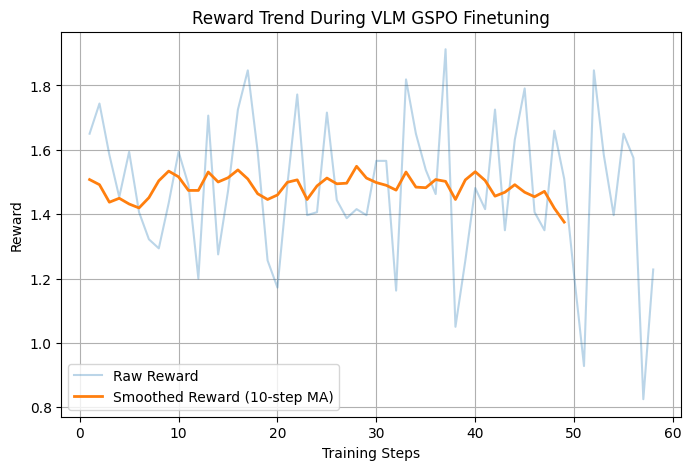

In [21]:
import matplotlib.pyplot as plt

# 提取奖励日志
steps, rewards = [], []
for log in trainer.state.log_history:
    if "reward" in log:
        steps.append(log["step"])
        rewards.append(log["reward"])

# 平滑处理
import numpy as np
window = 10
rewards_smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8, 5))
plt.plot(steps, rewards, alpha=0.3, label="Raw Reward")
plt.plot(steps[:len(rewards_smooth)], rewards_smooth, label=f"Smoothed Reward ({window}-step MA)", linewidth=2)
plt.xlabel("Training Steps")
plt.ylabel("Reward")
plt.title("Reward Trend During VLM GSPO Finetuning")
plt.grid(True)
plt.legend()
plt.show()

## 七、训练后推理



验证模型是否真的「学到了」我们通过奖励机制强化的行为，包括：

✔ 是否遵循` <REASONING>/<SOLUTION>` 输出格式

✔ 是否能根据图像内容进行推理

✔ 是否能给出正确答案

✔ 推理链是否更简洁、更稳定

✔ 是否不再输出 "addCriterion" 等异常 token

### 7.1 训练后单条样例推理

随机取一个测试样例（第 550 条）,再次调用 tokenizer，将视觉和文本一起编码,进行推理

In [22]:
image = train_dataset[450]["image"]
prompt = train_dataset[450]["prompt"]

inputs = tokenizer(
    image,
    prompt,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 1024,
                   use_cache = True, temperature = 1.0, min_p = 0.1)

<REASONING>
Let's analyze the objects in the image step by step.

First, let's identify and list all the objects present in the image:

1.  A small blue cube (left side)
2.  A small gray metallic cylinder (behind the purple cylinder)
3.  A small purple cylinder (center, behind the blue cylinder)
4.  A small blue cylinder (front center)
5.  A small blue sphere (center, behind the green cylinder)
6.  A large blue sphere (center back)
7.  A large green metallic cylinder (right front)
8.  A large yellow metallic cylinder (right back)

Total objects: 8.

Now, let's apply the subtraction rules:

Rule 1: "Subtract all small purple metallic spheres."
- Looking at the objects, there are no purple spheres at all. There is a small purple cylinder, but it is not a sphere. So, we subtract 0 objects based on this rule.

Rule 2: "Subtract all small purple things."
- This refers to the small purple cylinder. It is small and purple. We must subtract this one object.

So, we start with 8 objects.
We sub

### 7.2 训练后验证集评估

In [23]:
after_records = evaluate_with_details(
    eval_dataset,
    model,
    tokenizer,
    max_new_tokens=512,
    device="cuda",
)

total = len(after_records)
correct = sum(r["correct"] for r in after_records)
format_ok = sum(r["format_ok"] for r in after_records)

print(f"[After RL] Eval samples = {total}")
print(f"[After RL] Accuracy     = {correct / total:.3f}")
print(f"[After RL] Format rate  = {format_ok / total:.3f}")


Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 100/100 [59:55<00:00, 35.96s/it] 

[After RL] Eval samples = 100
[After RL] Accuracy     = 0.060
[After RL] Format rate  = 0.840


In [24]:
import json

with open("after_records.json", "w") as f:
    json.dump(after_records, f, indent=4)

print("✅ after_records 已保存至 after_records.json")

✅ after_records 已保存至 after_records.json


### 7.3 找不同 “训练前错、训练后对”的对照样例

In [25]:
import json

# 读取本地 JSON 文件
with open('baseline_records.json', 'r', encoding='utf-8') as f:
    baseline_records = json.load(f)

with open('after_records.json', 'r', encoding='utf-8') as f:
    after_records = json.load(f)

# 对比并收集“前错后对”的样本
improved_cases = []

for base, aft in zip(baseline_records, after_records):
    if (not base.get("correct")) and aft.get("correct"):
        improved_cases.append({
            "idx": base.get("idx"),
            "gold": base.get("gold"),
            "before_pred": base.get("pred"),
            "after_pred": aft.get("pred"),
            "before_completion": base.get("completion"),
            "after_completion": aft.get("completion"),
        })

print(f"Number of improved cases (wrong -> correct): {len(improved_cases)}")

# 如需保存输出结果，可以加这一行
# with open('improved_cases.json', 'w', encoding='utf-8') as f:
#     json.dump(improved_cases, f, ensure_ascii=False, indent=4)


Number of improved cases (wrong -> correct): 1


In [26]:
improved_cases = []

for base, aft in zip(baseline_records, after_records):
    # 只关注：前错后对的样本
    if (not base["correct"]) and aft["correct"]:
        improved_cases.append({
            "idx": base["idx"],
            "gold": base["gold"],
            "before_pred": base["pred"],
            "after_pred": aft["pred"],
            "before_completion": base["completion"],
            "after_completion": aft["completion"],
        })

print(f"Number of improved cases (wrong -> correct): {len(improved_cases)}")


Number of improved cases (wrong -> correct): 1


In [27]:
for i, case in enumerate(improved_cases[:5]):
    print(f"\n====== Case #{i} (dataset idx = {case['idx']}) ======")
    print(f"Gold answer       : {case['gold']}")
    print(f"Before RL pred    : {case['before_pred']}")
    print(f"After  RL pred    : {case['after_pred']}")
    print("\n--- Before RL completion ---")
    print(case["before_completion"])
    print("\n--- After RL completion ---")
    print(case["after_completion"])



====== Case #0 (dataset idx = 59) ======
Gold answer       : 991
Before RL pred    : 991.0
After  RL pred    : 991

--- Before RL completion ---
<REASONING>
To find the highest value of the navy blue bar, I need to:
1. Identify the navy blue bars in the chart, which represent "Acquaintance" incidents.
2. Read the numerical value on top of each navy blue bar for each year from 01/02 to 18/19.
3. Compare all these values to find the maximum.
4. The values for navy blue bars are: 917, 991, 941, 893, 879, 896, 816, 721, 732, 756, 832, 777, 660, 604, 548, 629, 459.
5. Among these, the highest value is 991, which corresponds to the year 02/03.
</REASONING>

<SOLUTION>991.0</SOLUTION><|im_end|>

--- After RL completion ---
<REASONING>
To find the highest value of the navy blue bar, I need to:
1. Identify all the navy blue bars in the chart, which represent "Acquaintance" incidents.
2. Read the numerical values written on top of each navy blue bar.
3. Compare these values to find the maximum.

## 八、保存加载训练后的模型

### 8.1 保存 LoRA 适配器（LoRA adapters）

save_pretrained() 用于把当前模型训练出的 LoRA 权重保存在本地。

如果你想在线保存到 Hugging Face Hub，可以使用 push_to_hub()，但要提供访问 Token。

⚠ 这里保存的只包括 LoRA 的微调参数（Adapter），并不是完整模型！

💡如果你想导出成完整模型（例如 16bit 或 GGUF 用于本地推理），需要继续往下阅读课件内容

In [28]:
model.save_pretrained("grpo_lora")  # Local saving
tokenizer.save_pretrained("grpo_lora")
# model.push_to_hub("your_name/grpo_lora", token = "...") # Online saving
# processor.push_to_hub("your_name/grpo_lora", token = "...") # Online saving

[]

### 8.2  验证 LoRA 是否真正被训练

In [34]:
from safetensors import safe_open

tensors = {}
with safe_open("grpo_lora/adapter_model.safetensors", framework = "pt") as f:
    # Verify both A and B are non zero
    for key in f.keys():
        tensor = f.get_tensor(key)
        n_zeros = (tensor == 0).sum() / tensor.numel()
        assert(n_zeros.item() != tensor.numel())

LoRA 的核心是两组矩阵：A 和 B。它们是在微调过程中学习出的。

- 查看训练好的 adapter_model.safetensors 文件；

- 遍历里面的所有 tensor；

- 计算每个 tensor 中“为零的元素数量”占比；

- assert(n_zeros != 1) 表示：

    - 如果整个矩阵全是 0，则说明 LoRA 根本没训练成功（毫无变化）。

    - 只有不为 0，才说明学习到了内容。

### 8.3 保存为VLLM可用的float16

⚙ LoRA 训练完成后，只保存适配器参数不能直接用于推理。

要方便部署（例如使用 vLLM、LM Studio、Ollama 等推理框架），就需要把 LoRA 与基础模型进行合并（Merge），并导出为特定精度格式。

下面是Unsloth支撑的格式和精度：

We also support saving to `float16` directly. Select `merged_16bit` for float16 or `merged_4bit` for int4. We also allow `lora` adapters as a fallback. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens.

In [30]:
# Merge to 16bit
if False: model.save_pretrained_merged("model", tokenizer, save_method = "merged_16bit",)
if False: model.push_to_hub_merged("hf/model", tokenizer, save_method = "merged_16bit", token = "")

# Merge to 4bit
if False: model.save_pretrained_merged("model", tokenizer, save_method = "merged_4bit",)
if False: model.push_to_hub_merged("hf/model", tokenizer, save_method = "merged_4bit", token = "")

# Just LoRA adapters
if False:
    model.save_pretrained("model")
    tokenizer.save_pretrained("model")
if False:
    model.push_to_hub("hf/model", token = "")
    tokenizer.push_to_hub("hf/model", token = "")

### 8.4 将模型导出为 GGUF / llama.cpp 格式


Unsloth会自动克隆 llama.cpp，并默认保存为 q8_0 量化格式。
也支持所有量化方法，比如 q4_k_m。
本地保存使用 save_pretrained_gguf，上传到 Hugging Face 使用 push_to_hub_gguf。

部分支持的量化方法 (full list on our [Wiki page](https://github.com/unslothai/unsloth/wiki#gguf-quantization-options)):
* `q8_0` - 转换速度快，资源占用较高，但通常可以接受。
* `q4_k_m` - 推荐。对一半的 attention.wv 和 feed_forward.w2 张量采用 Q6_K，其余使用 Q4_K。
* `q5_k_m` - 推荐。对一半的 attention.wv 和 feed_forward.w2 张量采用 Q6_K，其余使用 Q5_K。


In [31]:
# Save to 8bit Q8_0
if False: model.save_pretrained_gguf("model", tokenizer,)
# Remember to go to https://huggingface.co/settings/tokens for a token!
# And change hf to your username!
if False: model.push_to_hub_gguf("hf/model", tokenizer, token = "")

# Save to 16bit GGUF
if False: model.save_pretrained_gguf("model", tokenizer, quantization_method = "f16")
if False: model.push_to_hub_gguf("hf/model", tokenizer, quantization_method = "f16", token = "")

# Save to q4_k_m GGUF
if False: model.save_pretrained_gguf("model", tokenizer, quantization_method = "q4_k_m")
if False: model.push_to_hub_gguf("hf/model", tokenizer, quantization_method = "q4_k_m", token = "")

# Save to multiple GGUF options - much faster if you want multiple!
if False:
    model.push_to_hub_gguf(
        "hf/model", # Change hf to your username!
        tokenizer,
        quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
        token = "",
    )